# <center>The Voice of the Customer<center>

---
### `Project:`Unstructured Data Pipeline for Product Intelligence
##### - `The Problem:` Amazon Alexa reviews contain mixed sentiments that star ratings alone can't capture.
##### - `The Solution:` Built an NLP pipeline using Python (spaCy & NLTK) to "condition" unstructured text, splitting complex sentences to perform Aspect-Based Sentiment Analysis.
##### - `The Impact:` Identified "Time/Latency" as a key customer pain point that was statistically hidden in general positive reviews.

---
### This project analyze the Unstructured data of product reviews and Social media mentions. Instead of just saying "Positive," we build a pipeline to Extract entities, Sentiment mapping.

### Tools we use:
- `Pandas` - Data Handling
- `spaCy` - To identify the nouns, conditioning the text and to remove noise
- `NLTK` - To conditioning the text and to remove noise
- `Wordclouds` - To show the results
- `Seaborn` - To show the results
- `VADER` or `TextBlob` - To calculate the sentiment score.

## Phase 1: "Conditioning" (Data Cleaning)

### The Workflow 
1. Tokenization
2. Lemmatization
3. Noise Removal

## Phase 2: Entity Relationship & Sentiment

### Target Output:

* Entity: Camera | Sentiment: Positive
* Entity: Battery | Sentiment: Negative

## Phase 3: The Insight Dashbaord

### We will create a `Heatmap` or `Frequency chart` that shows which product features are causing the most frustration.
---

#### Installing required libraries

In [2]:
!pip install spacy nltk pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!python -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.3/12.8 MB 5.1 MB/s eta 0:00:03
     ------ --------------------------------- 2.1/12.8 MB 4.6 MB/s eta 0:00:03
     -------- ------------------------------- 2.6/12.8 MB 3.7 MB/s eta 0:00:03
     ------------ --------------------------- 3.9/12.8 MB 4.3 MB/s eta 0:00:03
     ---------------- ----------------------- 5.2/12.8 MB 4.7 MB/s eta 0:00:02
     ---------------- ----------------------- 5.2/12.8 MB 4.7 MB/s eta 0:00:02
     ---------------------- ----------------- 7.1/12.8 MB 4.7 MB/s eta 0:00:02
     -------------------------- ------------- 8.4/12.8 MB 4.8 MB/s eta 0:00:01
     ------------------------------ --------- 9.7/12.8 MB 4.9 MB/s eta 0:0

In [4]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

#### Downloading stopwords from Natural Language Tool Kit

In [5]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\itsme\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Load the Dataset

In [6]:
data = pd.read_csv('amazon_reviews.csv')
data

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1
...,...,...,...,...,...
3145,5,30-Jul-18,Black Dot,"Perfect for kids, adults and everyone in betwe...",1
3146,5,30-Jul-18,Black Dot,"Listening to music, searching locations, check...",1
3147,5,30-Jul-18,Black Dot,"I do love these things, i have them running my...",1
3148,5,30-Jul-18,White Dot,Only complaint I have is that the sound qualit...,1


## 1. Clean the text data

In [7]:
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '',str(text))
    text = text.lower()
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

#### Apply the cleaning function

In [8]:
data['cleaned_reviews'] = data['verified_reviews'].apply(clean_text)
data['cleaned_reviews']

0                                               love echo
1                                                   loved
2       sometimes playing game answer question correct...
3       lot fun thing yr old learns dinosaurs control ...
4                                                   music
                              ...                        
3145                         perfect kids adults everyone
3146    listening music searching locations checking t...
3147    love things running entire home tv lights ther...
3148    complaint sound quality isnt great mostly use ...
3149                                                 good
Name: cleaned_reviews, Length: 3150, dtype: str

In [9]:
print("Original Review: ", data['verified_reviews'][0])
print("Cleaned Review: ", data['cleaned_reviews'][0])

Original Review:  Love my Echo!
Cleaned Review:  love echo


## 2. Aspect Based Sentiment Analysis (ABSA)

##### `spaCy` to find the nouns (the "What") and `vader` to find the sentiment (the "How")

In [10]:
import spacy
from nltk.sentiment.vader import SentimentIntensityAnalyzer

##### Loading spacy an english model 

In [11]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\itsme\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [26]:
nlp = spacy.load("en_core_web_sm")
sid = SentimentIntensityAnalyzer()

##### Target Review. Here we extract the entity or the aspect we looking for.

In [19]:
review = "The sound quality is great but the charging cord is too short."

#### Tokenization

In [20]:
doc = nlp(review)
entities = [token.text for token in doc if token.pos_ in ["NOUN", "PROPN"]]

#### Sentiment Scoring

In [22]:
Scores = sid.polarity_scores(review)

In [24]:
print("Detected Entities: ", entities)
print("Overall Score: ", Scores)

Detected Entities:  ['quality', 'cord']
Overall Score:  {'neg': 0.0, 'neu': 0.812, 'pos': 0.188, 'compound': 0.3716}


---
##### - In the above result the sentiment score showing neutral with 81.2%. So that, the model sees more "facts" than "feelings".
##### - Now we need to split the sentence again because, the score is showing neutral sentiment score. If we consider the review is neutral, we miss the fact that customers love the sound but hate the cord.
##### - To fix this, we need to split sentence by the "but" before analyzing it. (A common trick in "conditioning" unstructured data.
---

#### 1. The Manual logic (The "Why")
##### (Now, isolate the words into different segments like "but", "however", "although")

In [27]:
segments = review.split("but")

for seg in segments:
    sentiment = sid.polarity_scores(seg)
    print("Segment: ", seg.strip(), "| Sentiment: ", sentiment['compound'])

Segment:  The sound quality is great | Sentiment:  0.6249
Segment:  the charging cord is too short. | Sentiment:  0.0


##### 1. The sound quality is highly poositive (62.49%).
##### 2. But, the charging cord is negative (0.0).
##### Conclusion: Now, we can say clearly that the problem is in different department like the the cord is (Engineering) and the sound is (Audio).
---

#### 2. The Automated Scalar (The "How")
##### Here, we use a technique called "Dependancy Parsing." This is where the AI understands the "grammer tree" of a sentence to see which adjective belongs to which noun.

In [33]:
def extract_aspect_sentiment(text):
    doc = nlp(text)
    results = []

    for token in doc:
        if token.pos_ == "NOUN":
            adjectives = [child.text for child in token.children if child.pos_ == "ADJ"]
            if adjectives:
                adj_sent = sid.polarity_scores(" ".join(adjectives))['compound']
                results.append({'aspect': token.text, 'sentiment': adj_sent})
    return results

In [34]:
data_subset = data.head(100).copy()
data_subset['aspect_analysis'] = data_subset['verified_reviews'].apply(extract_aspect_sentiment)

In [35]:
exploded_data = data_subset.explode('aspect_analysis').dropna(subset=['aspect_analysis'])

final_results = pd.concat([exploded_data.drop(['aspect_analysis'], axis=1),
                           exploded_data['aspect_analysis'].apply(pd.Series)], axis=1)

In [38]:
final_results[['verified_reviews','aspect', 'sentiment']]

,verified_reviews,aspect,sentiment
3,I have had a lot of fun with this thing. My 4 ...,learns,0.0000
3,I have had a lot of fun with this thing. My 4 ...,sound,0.4215
5,I received the echo as a gift. I needed anothe...,speaker,0.4019
6,"Without having a cellphone, I cannot use many ...",alarm,0.6249
6,"Without having a cellphone, I cannot use many ...",reason,0.0000
...,...,...,...
94,Love it! I was thinking about getting one and ...,types,0.0000
94,Love it! I was thinking about getting one and ...,countries,0.0000
94,Love it! I was thinking about getting one and ...,downside,0.0000
97,"Love the Echo !!! I love the size, material an...",lights,0.0000


## 3. The Insight

In [41]:
report = final_results.groupby('aspect')['sentiment'].mean().sort_values()
report

aspect
time          -0.051350
apps           0.000000
base           0.000000
assistant      0.000000
components     0.000000
commands       0.000000
collections    0.000000
day            0.000000
days           0.000000
countries      0.000000
featues        0.000000
generation     0.000000
family         0.000000
extent         0.000000
downside       0.000000
charger        0.000000
motivation     0.000000
member         0.000000
lights         0.000000
list           0.000000
learns         0.000000
improvement    0.000000
response       0.000000
reason         0.000000
place          0.000000
questions      0.000000
playlists      0.000000
price          0.000000
package        0.000000
pin            0.000000
need           0.000000
deal           0.000000
uses           0.000000
types          0.000000
unit           0.000000
toy            0.000000
things         0.000000
tips           0.000000
strips         0.000000
programs       0.000000
units          0.000000
devices  

In [42]:
print("Top complaints (Negative sentiment): ")
print(report.head(5))

Top complaints (Negative sentiment): 
aspect
time         -0.05135
apps          0.00000
base          0.00000
assistant     0.00000
components    0.00000
Name: sentiment, dtype: float64


In [43]:
print("Top Praises (Positive sentiment): ")
print(report.tail(5))

Top Praises (Positive sentiment): 
aspect
speaker       0.59625
alarm         0.62490
fun           0.62490
technology    0.62490
gift          0.63690
Name: sentiment, dtype: float64


### 4. The Visualization

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

top_aspects = final_results['aspect'].value_counts().head(10).index
viz_data = final_results[final_results['aspect'].isin(top_aspects)]

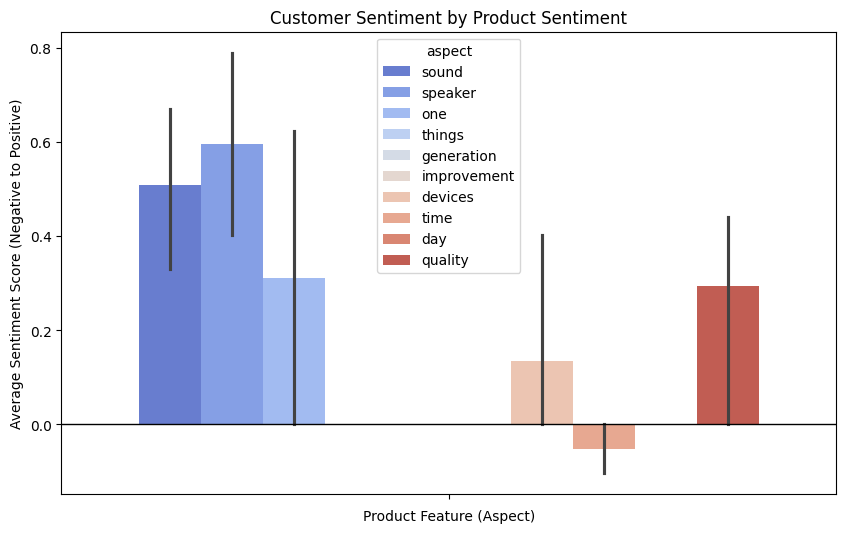

In [52]:
plt.figure(figsize=(10,6))
sns.barplot(data = viz_data, hue='aspect', y='sentiment', palette='coolwarm')
plt.axhline(0, color='black', lw=1)
plt.title('Customer Sentiment by Product Sentiment')
plt.ylabel('Average Sentiment Score (Negative to Positive)')
plt.xlabel('Product Feature (Aspect)')
plt.xticks(rotation=45)
plt.show()